## Sigmoid

In notebook 01 the perceptron used a step function: the output jumps abruptly between 0 and 1, with no in-between. That means the correction applied during training is always the same size, whether the prediction was barely wrong or wildly wrong — like a rocket correcting its course by a fixed amount regardless of whether it drifted 2° or 40° off course.

Sigmoid replaces that jump with a smooth S-shaped curve, so the correction can scale with how wrong the prediction actually is:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

As $z \to -\infty$, $\sigma(z) \to 0$. As $z \to +\infty$, $\sigma(z) \to 1$. At $z=0$, $\sigma(z) = 0.5$ exactly.

Its derivative — the actual "correction factor" used during training — can be written in terms of the function's own output, without recomputing the exponential:

$$\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def sigmoid(z):
    s = 1/(1+np.e**-z)
    return s

def sigmoid_derivative(z):
    g = sigmoid(z) * (1-sigmoid(z))
    return g

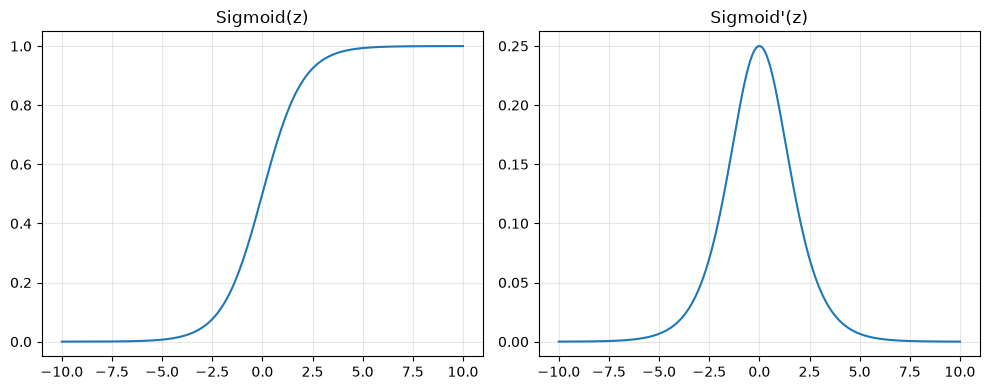

In [8]:
z = np.linspace(-10, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(z, sigmoid(z))
axes[0].set_title('Sigmoid(z)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, sigmoid_derivative(z))
axes[1].set_title("Sigmoid'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Vanishing gradient.** The derivative graph above shows the problem clearly: it peaks at 0.25 in the center and flattens toward 0 at both extremes — sigmoid *saturates* there. In a network with many stacked layers, the final correction is computed by multiplying the gradients of every layer together. If several of those gradients are small (because they're saturated), the product shrinks fast — the error barely reaches the earliest layers, and they stop learning effectively. It's like dragging a mistake from the very start of the network, gradually losing the signal that would correct it.

## ReLU (Rectified Linear Unit)

Sigmoid solves the step function's lack of gradient, but its derivative saturates near 0 at both extremes. ReLU takes a different approach: instead of squashing everything into a smooth curve, it does something much simpler — negative inputs are turned off (set to 0), and positive inputs pass through completely unchanged.

$$\text{ReLU}(z) = \max(0, z)$$

For any positive $z$, the derivative is exactly 1 — no saturation, ever. For any negative $z$, the derivative is exactly 0.

$$\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

In [9]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    array = z > 0
    return array.astype(float)

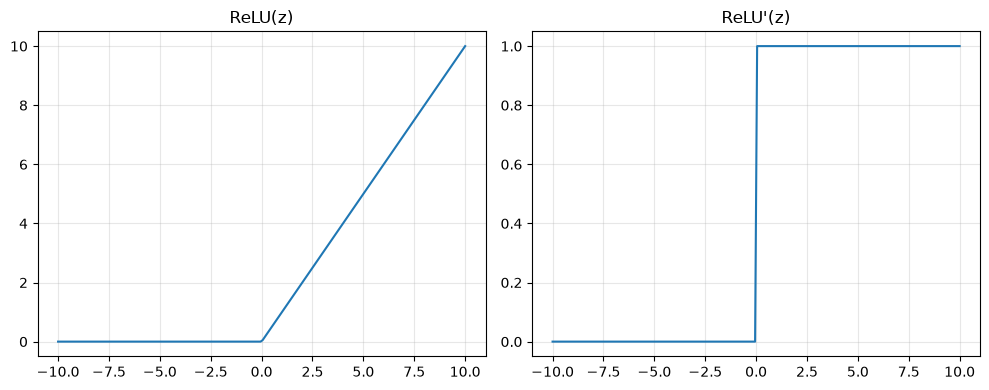

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(z, relu(z))
axes[0].set_title('ReLU(z)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, relu_derivative(z))
axes[1].set_title("ReLU'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Dying ReLU.** The derivative graph shows a clean step: 1 for every positive z, 0 for every negative z — no in-between. That's a strength on the positive side (the gradient never saturates, unlike sigmoid), but it creates a new problem on the negative side: if a neuron's input lands in negative territory during training, its gradient is exactly 0. Since the correction applied to the weights depends on that gradient, a correction of 0 means the neuron never updates again — it's permanently stuck, regardless of how much more training happens afterward.

## Softmax

Sigmoid and ReLU act element-wise — each output only depends on the matching input. Softmax is different: it's used when the network has to choose among several classes, and every output depends on **all** the logits together, because the whole vector has to sum to 1 (it's a probability distribution over classes — e.g. "66% cat, 24% dog, 10% bird").

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Numerical stability.** $e^x$ overflows for large $x$ (`np.exp(1000)` returns `inf`). Since subtracting a constant from every entry of $x$ doesn't change the result, we subtract $\max(x)$ before exponentiating — this guarantees the largest value exponentiated is $e^0 = 1$, so overflow can't happen:

$$\text{softmax}(x) = \text{softmax}(x - \max(x))$$

In [11]:
def softmax(x):
    maxi = x - np.max(x)
    expo = np.exp(maxi)
    summ = np.sum(expo)
    return expo/summ

Logits: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0000


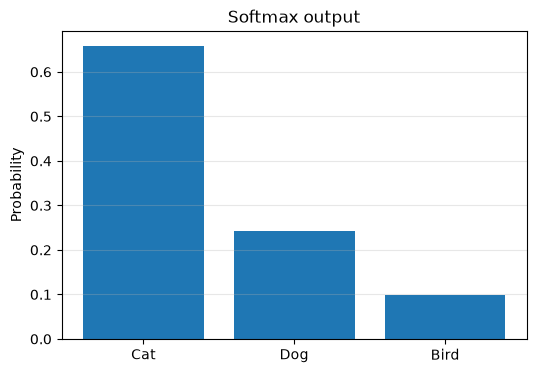

In [12]:
# Example: raw logits for 3 classes
logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)

print(f"Logits: {logits}")
print(f"Probabilities: {probs}")
print(f"Sum: {probs.sum():.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['Cat', 'Dog', 'Bird'], probs)
plt.ylabel('Probability')
plt.title('Softmax output')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Looking ahead to backprop.** Unlike sigmoid and ReLU, softmax's derivative isn't a simple element-wise expression — since every output depends on every input, the full derivative is a matrix (a Jacobian), not a single value per position. We won't code it here. But when softmax is paired with **cross-entropy loss** (notebook 03), the combined gradient collapses into a surprisingly simple expression:

$$\frac{\partial L}{\partial x_i} = \hat{y}_i - y_i$$

Just the predicted probability minus the true one-hot label. Worth deriving by hand once we get there — it's one of those simplifications that makes the whole backward pass tractable.

## Summary

| Function | Formula | Derivative | Key property |
|---|---|---|---|
| Sigmoid | $\dfrac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | Smooth, but saturates at the extremes (vanishing gradient) |
| ReLU | $\max(0, z)$ | $1$ if $z>0$ else $0$ | No saturation on the positive side, but neurons can die on the negative side |
| Softmax | $\dfrac{e^{x_i}}{\sum_j e^{x_j}}$ | Jacobian (simplifies with cross-entropy) | Depends on the whole vector, not element-wise — used for multi-class output |

**Next:** with a weighted sum (01) and non-linear activations (02) in hand, notebook 03 builds the multilayer perceptron and derives backpropagation.